<a href="https://colab.research.google.com/github/jadhavkushank-sudo/kushank-jadhav/blob/main/Website_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [92]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [93]:
df = pd.read_csv('/content/websit permormance analysis.csv')

In [94]:
df.head()

,# ----------------------------------------,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9
0,Session primary channel group (Default channel...,Date + hour (YYYYMMDDHH),Users,Sessions,Engaged sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count
1,Direct,2024041623,237,300,144,47.526666666666700,0.6075949367088610,4.673333333333330,0.48,1402
2,Organic Social,2024041719,208,267,132,32.09737827715360,0.6346153846153850,4.295880149812730,0.4943820224719100,1147
3,Direct,2024041723,188,233,115,39.93991416309010,0.6117021276595740,4.587982832618030,0.49356223175965700,1069
4,Organic Social,2024041718,187,256,125,32.16015625,0.6684491978609630,4.078125,0.48828125,1044


In [95]:
df.columns = df.iloc[0]
df = df.drop(index = 0).reset_index(drop = True)
df.columns = ['Channel group','DateHour','User','Sessions','Engaged sessions','avergae enagaement time per session','Engaged session per user','Events per session','Engagement rate','Event count']

In [96]:
df.head()

,Channel group,DateHour,User,Sessions,Engaged sessions,avergae enagaement time per session,Engaged session per user,Events per session,Engagement rate,Event count
0,Direct,2024041623,237,300,144,47.526666666666700,0.6075949367088610,4.673333333333330,0.48,1402
1,Organic Social,2024041719,208,267,132,32.09737827715360,0.6346153846153850,4.295880149812730,0.4943820224719100,1147
2,Direct,2024041723,188,233,115,39.93991416309010,0.6117021276595740,4.587982832618030,0.49356223175965700,1069
3,Organic Social,2024041718,187,256,125,32.16015625,0.6684491978609630,4.078125,0.48828125,1044
4,Organic Social,2024041720,175,221,112,46.918552036199100,0.64,4.529411764705880,0.5067873303167420,1001


In [97]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3182 entries, 0 to 3181
Data columns (total 10 columns):
 #   Column                               Non-Null Count  Dtype 
---  ------                               --------------  ----- 
 0   Channel group                        3182 non-null   object
 1   DateHour                             3182 non-null   object
 2   User                                 3182 non-null   object
 3   Sessions                             3182 non-null   object
 4   Engaged sessions                     3182 non-null   object
 5   avergae enagaement time per session  3182 non-null   object
 6   Engaged session per user             3182 non-null   object
 7   Events per session                   3182 non-null   object
 8   Engagement rate                      3182 non-null   object
 9   Event count                          3182 non-null   object
dtypes: object(10)
memory usage: 248.7+ KB


In [98]:
df['DateHour'] = pd.to_datetime(df['DateHour'], format = '%Y%m%d%H', errors = 'coerce')
numerical_cols = df.columns.drop(['Channel group','DateHour'])
df[numerical_cols] = df[numerical_cols].apply(pd.to_numeric, errors = 'coerce')
df['Hour'] = df['DateHour'].dt.hour

In [99]:
df.head()

,Channel group,DateHour,User,Sessions,Engaged sessions,avergae enagaement time per session,Engaged session per user,Events per session,Engagement rate,Event count,Hour
0,Direct,2024-04-16 23:00:00,237,300,144,47.526667,0.607595,4.673333,0.480000,1402,23
1,Organic Social,2024-04-17 19:00:00,208,267,132,32.097378,0.634615,4.295880,0.494382,1147,19
2,Direct,2024-04-17 23:00:00,188,233,115,39.939914,0.611702,4.587983,0.493562,1069,23
3,Organic Social,2024-04-17 18:00:00,187,256,125,32.160156,0.668449,4.078125,0.488281,1044,18
4,Organic Social,2024-04-17 20:00:00,175,221,112,46.918552,0.640000,4.529412,0.506787,1001,20


In [100]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3182 entries, 0 to 3181
Data columns (total 11 columns):
 #   Column                               Non-Null Count  Dtype         
---  ------                               --------------  -----         
 0   Channel group                        3182 non-null   object        
 1   DateHour                             3182 non-null   datetime64[ns]
 2   User                                 3182 non-null   int64         
 3   Sessions                             3182 non-null   int64         
 4   Engaged sessions                     3182 non-null   int64         
 5   avergae enagaement time per session  3182 non-null   float64       
 6   Engaged session per user             3182 non-null   float64       
 7   Events per session                   3182 non-null   float64       
 8   Engagement rate                      3182 non-null   float64       
 9   Event count                          3182 non-null   int64         
 10  Hour        

In [101]:
df.describe()

,DateHour,User,Sessions,Engaged sessions,avergae enagaement time per session,Engaged session per user,Events per session,Engagement rate,Event count,Hour
count,3182,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000
mean,2024-04-20 01:17:07.278441216,41.935889,51.192646,28.325581,66.644581,0.606450,4.675969,0.503396,242.272470,11.807040
min,2024-04-06 00:00:00,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000
25%,2024-04-13 02:15:00,20.000000,24.000000,13.000000,32.103034,0.561404,3.750000,0.442902,103.000000,6.000000
50%,2024-04-20 02:00:00,42.000000,51.000000,27.000000,49.020202,0.666667,4.410256,0.545455,226.000000,12.000000
75%,2024-04-26 22:00:00,60.000000,71.000000,41.000000,71.487069,0.750000,5.217690,0.633333,339.000000,18.000000
max,2024-05-03 23:00:00,237.000000,300.000000,144.000000,4525.000000,2.000000,56.000000,1.000000,1402.000000,23.000000
std,NaN,29.582258,36.919962,20.650569,127.200659,0.264023,2.795228,0.228206,184.440313,6.886686


Sessions and users over time


In [102]:
sns.set(style = 'whitegrid')


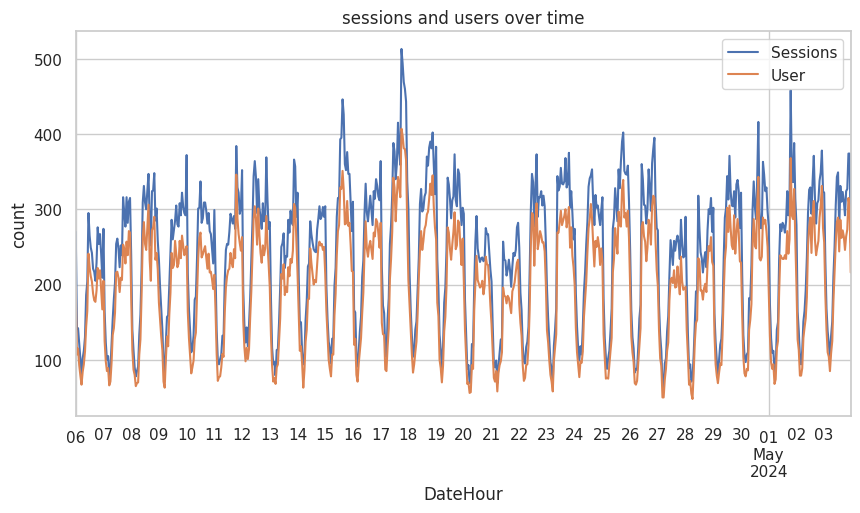

In [103]:
plt.figure(figsize = (10,5))
df.groupby('DateHour')[['Sessions','User']].sum().plot(ax=plt.gca())
plt.title('sessions and users over time')
plt.xlabel('DateHour')
plt.ylabel('count')
plt.show()


Total users by channel

/tmp/ipykernel_257/2984288455.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Channel group', y='User', estimator=np.sum, palette='viridis')


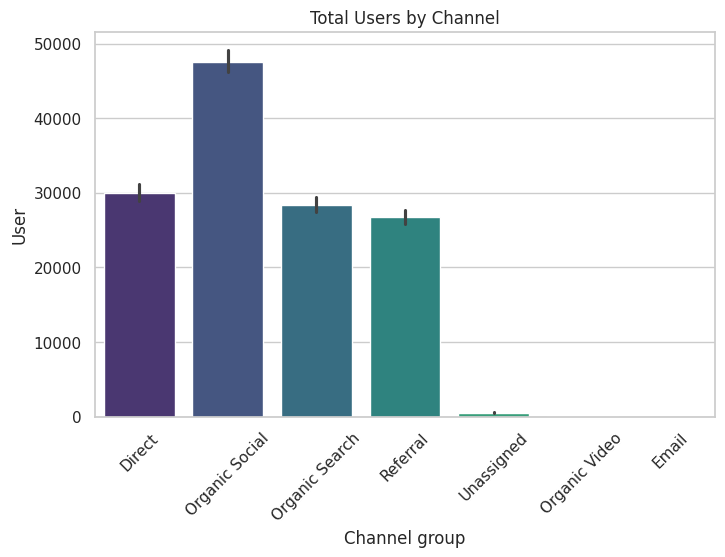

In [104]:
plt.figure(figsize=(8,5))
sns.barplot(data=df, x='Channel group', y='User', estimator=np.sum, palette='viridis')
plt.title('Total Users by Channel')
plt.xticks(rotation=45)
plt.show()

Average Engagement time by channel

/tmp/ipykernel_257/2650001887.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Channel group', y='avergae enagaement time per session', estimator = np.mean, palette='magma')


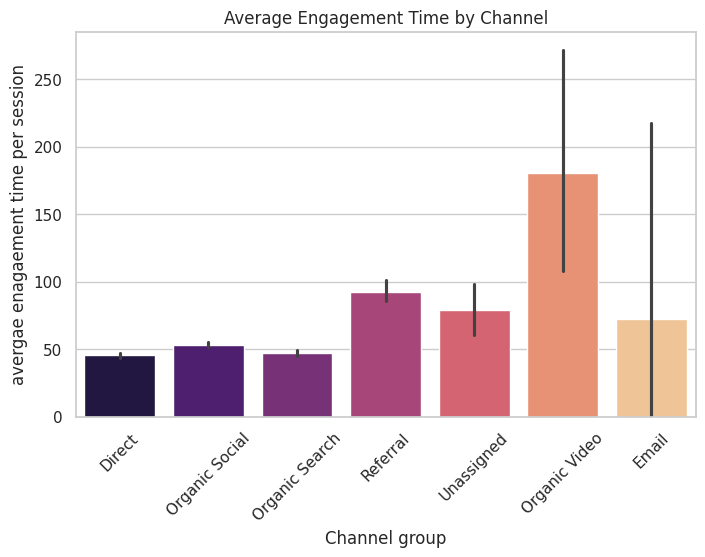

In [105]:
plt.figure(figsize=(8,5))
sns.barplot(data=df, x='Channel group', y='avergae enagaement time per session', estimator = np.mean, palette='magma')
plt.title('Average Engagement Time by Channel')
plt.xticks(rotation=45)
plt.show()

In [106]:
df.head()

,Channel group,DateHour,User,Sessions,Engaged sessions,avergae enagaement time per session,Engaged session per user,Events per session,Engagement rate,Event count,Hour
0,Direct,2024-04-16 23:00:00,237,300,144,47.526667,0.607595,4.673333,0.480000,1402,23
1,Organic Social,2024-04-17 19:00:00,208,267,132,32.097378,0.634615,4.295880,0.494382,1147,19
2,Direct,2024-04-17 23:00:00,188,233,115,39.939914,0.611702,4.587983,0.493562,1069,23
3,Organic Social,2024-04-17 18:00:00,187,256,125,32.160156,0.668449,4.078125,0.488281,1044,18
4,Organic Social,2024-04-17 20:00:00,175,221,112,46.918552,0.640000,4.529412,0.506787,1001,20


Engagement Rate Ditribution by channel

/tmp/ipykernel_257/355952855.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Channel group', y='Engagement rate', palette='coolwarm')


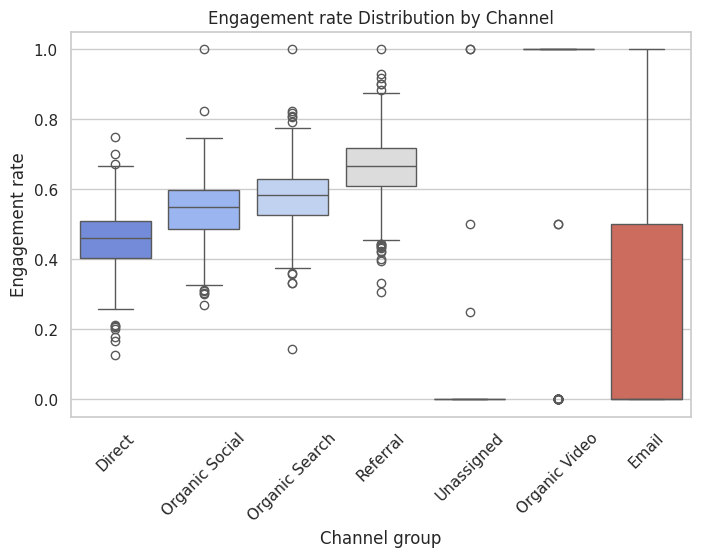

In [107]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Channel group', y='Engagement rate', palette='coolwarm')
plt.title('Engagement rate Distribution by Channel')
plt.xticks(rotation=45)
plt.show()

Engaged vs Non engaged sessions

In [108]:
df.head()

,Channel group,DateHour,User,Sessions,Engaged sessions,avergae enagaement time per session,Engaged session per user,Events per session,Engagement rate,Event count,Hour
0,Direct,2024-04-16 23:00:00,237,300,144,47.526667,0.607595,4.673333,0.480000,1402,23
1,Organic Social,2024-04-17 19:00:00,208,267,132,32.097378,0.634615,4.295880,0.494382,1147,19
2,Direct,2024-04-17 23:00:00,188,233,115,39.939914,0.611702,4.587983,0.493562,1069,23
3,Organic Social,2024-04-17 18:00:00,187,256,125,32.160156,0.668449,4.078125,0.488281,1044,18
4,Organic Social,2024-04-17 20:00:00,175,221,112,46.918552,0.640000,4.529412,0.506787,1001,20


In [111]:
session_df = df.groupby('Channel group')[['Sessions', 'Engaged sessions']].sum().reset_index()
session_df['Non-Engaged'] = session_df['Sessions'] - session_df['Engaged sessions']
sessions_df_melted = session_df.melt(id_vars = 'Channel group',value_vars=['Engaged sessions','Non-Engaged'])



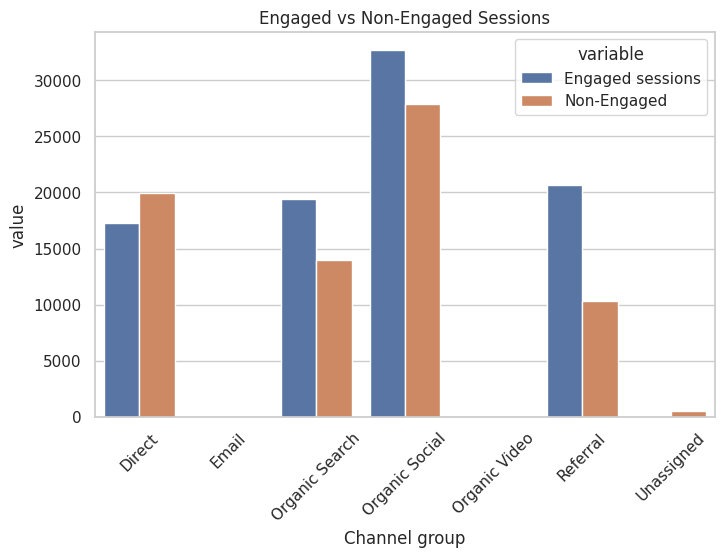

In [118]:
session_df = df.groupby('Channel group')[['Sessions', 'Engaged sessions']].sum().reset_index()
session_df['Non-Engaged'] = session_df['Sessions'] - session_df['Engaged sessions']
sessions_df_melted = session_df.melt(id_vars = 'Channel group',value_vars=['Engaged sessions','Non-Engaged'])

plt.figure(figsize=(8,5))
sns.barplot(data=sessions_df_melted, x='Channel group', y='value',hue="variable")
plt.title('Engaged vs Non-Engaged Sessions')
plt.xticks(rotation=45)
plt.show()

In [115]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3182 entries, 0 to 3181
Data columns (total 11 columns):
 #   Column                               Non-Null Count  Dtype         
---  ------                               --------------  -----         
 0   Channel group                        3182 non-null   object        
 1   DateHour                             3182 non-null   datetime64[ns]
 2   User                                 3182 non-null   int64         
 3   Sessions                             3182 non-null   int64         
 4   Engaged sessions                     3182 non-null   int64         
 5   avergae enagaement time per session  3182 non-null   float64       
 6   Engaged session per user             3182 non-null   float64       
 7   Events per session                   3182 non-null   float64       
 8   Engagement rate                      3182 non-null   float64       
 9   Event count                          3182 non-null   int64         
 10  Hour        

Traffic by hour and channel

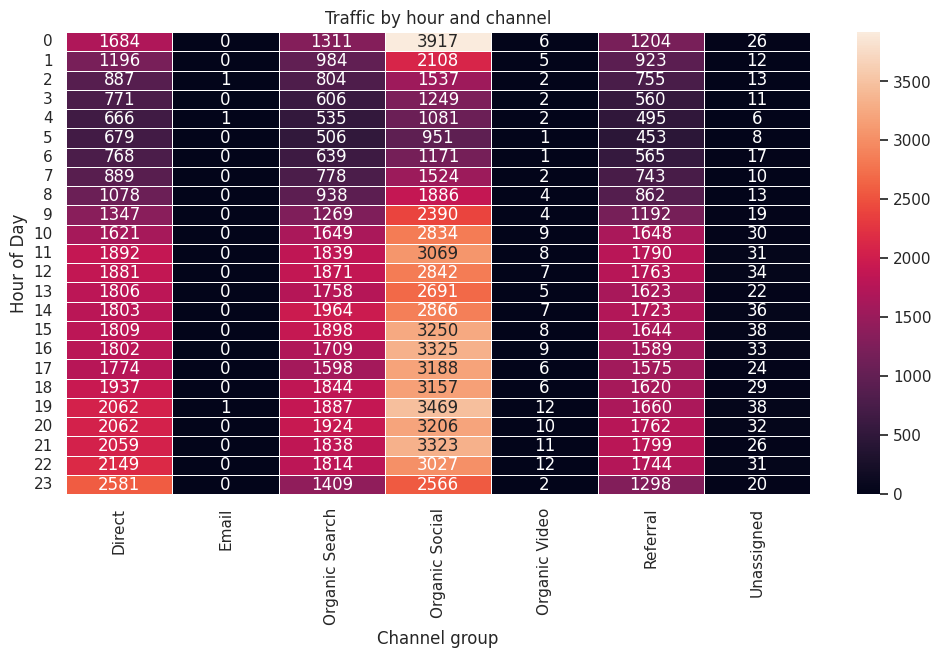

In [128]:
heatmap_data = df.groupby(['Hour','Channel group'])['Sessions'].sum().unstack().fillna(0)

plt.figure(figsize=(12,6))
sns.heatmap(heatmap_data,linewidths=.5, annot=True, fmt='.0f')
plt.title('Traffic by hour and channel')
plt.xlabel('Channel group')
plt.ylabel('Hour of Day')
plt.show()

Engagement rate vs sessions channel

In [129]:
df.head()

,Channel group,DateHour,User,Sessions,Engaged sessions,avergae enagaement time per session,Engaged session per user,Events per session,Engagement rate,Event count,Hour
0,Direct,2024-04-16 23:00:00,237,300,144,47.526667,0.607595,4.673333,0.480000,1402,23
1,Organic Social,2024-04-17 19:00:00,208,267,132,32.097378,0.634615,4.295880,0.494382,1147,19
2,Direct,2024-04-17 23:00:00,188,233,115,39.939914,0.611702,4.587983,0.493562,1069,23
3,Organic Social,2024-04-17 18:00:00,187,256,125,32.160156,0.668449,4.078125,0.488281,1044,18
4,Organic Social,2024-04-17 20:00:00,175,221,112,46.918552,0.640000,4.529412,0.506787,1001,20


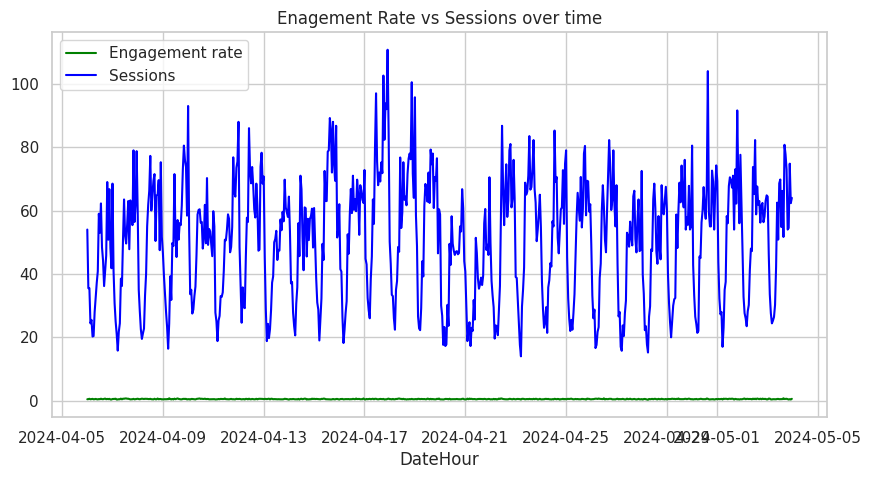

In [134]:
df_plot = df.groupby('DateHour')[['Engagement rate', 'Sessions']].mean().reset_index()

plt.figure(figsize=(10,5))
plt.plot(df_plot['DateHour'],df_plot['Engagement rate'], label= 'Engagement rate', color='green')
plt.plot(df_plot['DateHour'],df_plot['Sessions'], label= 'Sessions', color='blue')
plt.title('Enagement Rate vs Sessions over time')
plt.xlabel('DateHour')
plt.legend()
plt.grid(True)
plt.show()